# Practice quiz: Train the model with gradient descent

## Question 1: Understanding the Effect of a Negative Derivative

### Question:

Gradient descent is an algorithm for finding values of parameters $w$ and $b$ that minimize the cost function $J$.

repeat until convergence {
    $$
    w = w - \alpha \frac{\partial}{\partial w}J(w, b)
    $$
    $$
    b = b - \alpha \frac{\partial}{\partial b}J(w, b)
    $$
}

When $\frac{\partial J(w,b)}{\partial w}$ is a **negative number** (less than zero), what happens to $w$ after one update step?

- [ ] $w$ increases.
- [ ] $w$ decreases
- [ ] $w$ stays the same
- [ ] It is not possible to tell if $w$ will increase or decrease.

---

### Correct Answer:

✅ **$w$ increases.** is the correct answer.

---

### Explanation of Correct Answer:

Let's break down the gradient descent update rule step by step:

$$w = w - \alpha \frac{\partial J(w,b)}{\partial w}$$

Where:
- $w$ is the current parameter value
- $\alpha$ (alpha) is the **learning rate** - always a positive number (typically between 0 and 1)
- $\frac{\partial J(w,b)}{\partial w}$ is the **derivative** (slope) at the current point

**When the derivative is negative:**

If $\frac{\partial J(w,b)}{\partial w} < 0$, then we are subtracting a negative number from $w$:

$$w_{\text{new}} = w_{\text{old}} - \alpha \times (\text{negative number})$$

Subtracting a negative number is the same as **adding** a positive number:

$$w_{\text{new}} = w_{\text{old}} + \alpha \times |\text{negative number}|$$

Therefore, $w_{\text{new}} > w_{\text{old}}$ - **$w$ increases!**

---

### Visual Intuition:

Imagine you're standing on a hill (the cost function) and you want to walk downhill to the valley (the minimum).

- **Positive derivative** (sloping uphill to the right): To go downhill, you need to walk **left** (decrease $w$)
- **Negative derivative** (sloping downhill to the right): To go downhill, you need to walk **right** (increase $w$)


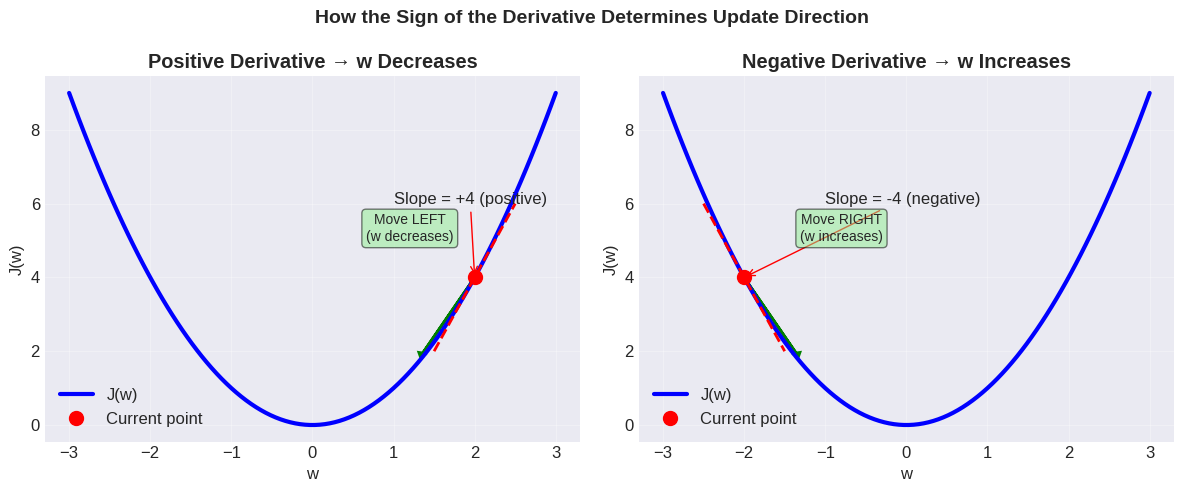

In [38]:
# Visualizing the effect of negative derivative
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create a simple quadratic function
x = np.linspace(-3, 3, 100)
y = x**2

# Case 1: Positive derivative (at x = 2)
axes[0].plot(x, y, 'b-', linewidth=3, label='J(w)')
axes[0].plot(2, 4, 'ro', markersize=10, label='Current point')
axes[0].annotate('Slope = +4 (positive)', xy=(2, 4), xytext=(1, 6),
                arrowprops=dict(arrowstyle='->', color='red'))

# Tangent line for positive derivative
tangent_x = np.linspace(1.5, 2.5, 10)
tangent_y = 4 + 4 * (tangent_x - 2)  # slope = 4
axes[0].plot(tangent_x, tangent_y, 'r--', linewidth=2)

# Show update direction (left)
new_x = 2 - 0.2 * 4  # alpha = 0.2
new_y = new_x**2
axes[0].arrow(2, 4, (new_x - 2) * 0.8, (new_y - 4) * 0.8,
             head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
axes[0].text(1.2, 5, 'Move LEFT\n(w decreases)', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[0].set_xlabel('w')
axes[0].set_ylabel('J(w)')
axes[0].set_title('Positive Derivative → w Decreases', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Case 2: Negative derivative (at x = -2)
axes[1].plot(x, y, 'b-', linewidth=3, label='J(w)')
axes[1].plot(-2, 4, 'ro', markersize=10, label='Current point')
axes[1].annotate('Slope = -4 (negative)', xy=(-2, 4), xytext=(-1, 6),
                arrowprops=dict(arrowstyle='->', color='red'))

# Tangent line for negative derivative
tangent_x = np.linspace(-2.5, -1.5, 10)
tangent_y = 4 + (-4) * (tangent_x + 2)  # slope = -4
axes[1].plot(tangent_x, tangent_y, 'r--', linewidth=2)

# Show update direction (right)
new_x = -2 - 0.2 * (-4)  # subtracting negative = adding positive
new_y = new_x**2
axes[1].arrow(-2, 4, (new_x + 2) * 0.8, (new_y - 4) * 0.8,
             head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
axes[1].text(-0.8, 5, 'Move RIGHT\n(w increases)', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[1].set_xlabel('w')
axes[1].set_ylabel('J(w)')
axes[1].set_title('Negative Derivative → w Increases', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('How the Sign of the Derivative Determines Update Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Explanation of Incorrect Options:

| Option | Why It's Incorrect |
|--------|---------------------|
| **$w$ decreases** | This would happen if the derivative were **positive** (greater than zero). With a negative derivative, we subtract a negative number, which adds to $w$. |
| **$w$ stays the same** | This would only happen if the derivative were exactly **zero**, which means we're already at a minimum. A negative derivative means we're not at the minimum yet. |
| **It is not possible to tell** | We can absolutely tell! The update rule is deterministic - given a negative derivative and a positive learning rate, $w$ will **always increase**. |

---

### Real-World Analogy: Finding the Lowest Point in a Valley

Imagine you're blindfolded in a dark valley and want to find the lowest point:

- **Your feet** = The current parameter $w$
- **The slope you feel under your feet** = The derivative $\frac{\partial J}{\partial w}$
- **Your step size** = The learning rate $\alpha$

**If the ground slopes DOWN to your RIGHT** (negative derivative):
- To go downhill, you need to step to the RIGHT
- This means **increasing** your position coordinate ($w$ increases)

**If the ground slopes DOWN to your LEFT** (positive derivative):
- To go downhill, you need to step to the LEFT
- This means **decreasing** your position coordinate ($w$ decreases)

The gradient descent algorithm automates this intuition mathematically!

---

## Question 2: Identifying the Correct Update Step for Parameter $b$

### Question:

For linear regression, what is the update step for parameter $b$?

- [ ] $b = b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$
- [ ] $b = b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$

---

### Correct Answer:

✅ **$b = b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$** is the correct answer.

---

### Explanation of Correct Answer:

For linear regression with the squared error cost function:

$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

The partial derivatives are:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$$

Notice the key difference:
- The derivative with respect to $w$ includes a multiplication by $x^{(i)}$
- The derivative with respect to $b$ does **not** include $x^{(i)}$

Therefore, the gradient descent update steps are:

$$w = w - \alpha \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$

$$b = b - \alpha \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$$

---

### Why This Difference Makes Sense Intuitively:

Think of the linear model $f(x) = wx + b$:

- **$w$ (slope)** determines how much the prediction changes when $x$ changes
- **$b$ (intercept)** is independent of $x$ - it's just a constant offset

When calculating how to adjust $w$, we need to consider **how much each training example's $x$ value amplifies or reduces the error**. That's why we multiply by $x^{(i)}$.

When calculating how to adjust $b$, we just look at the raw errors - $b$ affects all predictions equally regardless of $x$.



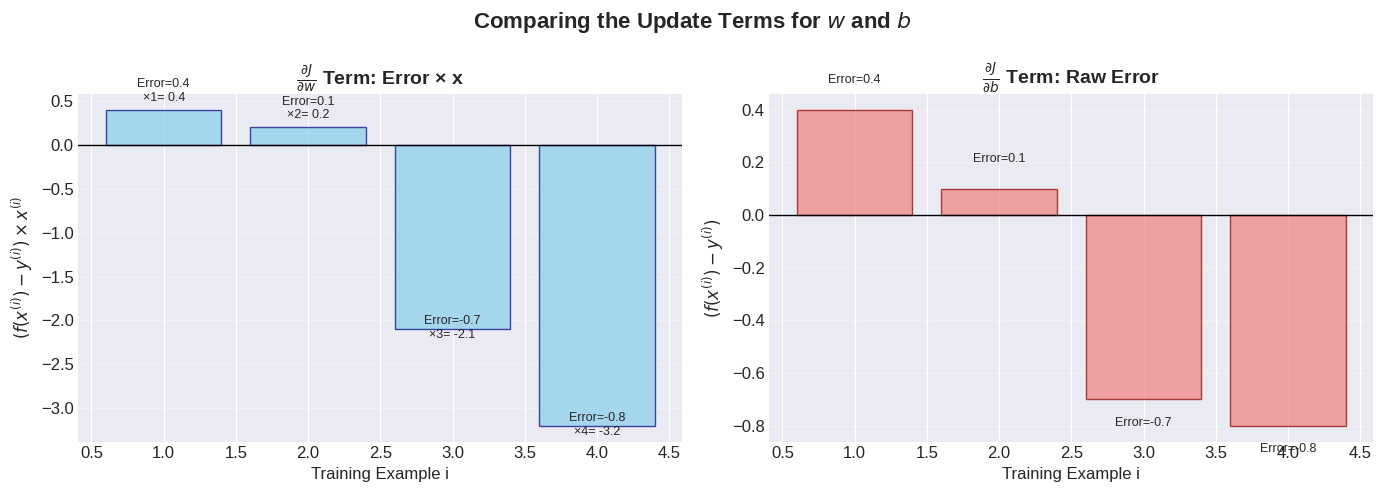

Sum for w update: -4.70
Sum for b update: -1.00

The w update weights errors by their corresponding x values.
The b update treats all errors equally.


In [39]:
# Visualizing the difference between w and b updates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample data
X_sample = np.array([1, 2, 3, 4])
y_sample = np.array([2.1, 3.9, 6.2, 7.8])
w_test, b_test = 1.5, 1.0
predictions = w_test * X_sample + b_test
errors = predictions - y_sample

# Plot 1: w update visualization
axes[0].bar(range(1, 5), errors * X_sample, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_xlabel('Training Example i', fontsize=12)
axes[0].set_ylabel('$(f(x^{(i)}) - y^{(i)}) \\times x^{(i)}$', fontsize=12)
axes[0].set_title('$\\frac{\\partial J}{\\partial w}$ Term: Error × x', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Add annotations
for i, (err, x) in enumerate(zip(errors, X_sample)):
    axes[0].text(i+1, err*x + 0.1 * np.sign(err*x),
                f'Error={err:.1f}\n×{x}= {err*x:.1f}',
                ha='center', fontsize=9)

# Plot 2: b update visualization
axes[1].bar(range(1, 5), errors, color='lightcoral', edgecolor='darkred', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Training Example i', fontsize=12)
axes[1].set_ylabel('$(f(x^{(i)}) - y^{(i)})$', fontsize=12)
axes[1].set_title('$\\frac{\\partial J}{\\partial b}$ Term: Raw Error', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

# Add annotations
for i, err in enumerate(errors):
    axes[1].text(i+1, err + 0.1 * np.sign(err),
                f'Error={err:.1f}',
                ha='center', fontsize=9)

plt.suptitle('Comparing the Update Terms for $w$ and $b$', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Sum for w update: {np.sum(errors * X_sample):.2f}")
print(f"Sum for b update: {np.sum(errors):.2f}")
print("\nThe w update weights errors by their corresponding x values.")
print("The b update treats all errors equally.")


### Explanation of the Incorrect Option:

| Option | Why It's Incorrect |
|--------|---------------------|
| $b = b - \alpha \frac{1}{m} \sum (f(x^{(i)}) - y^{(i)}) x^{(i)}$ | This is actually the update step for **$w$**, not $b$! The extra $x^{(i)}$ factor belongs with the slope parameter, not the intercept. Using this for $b$ would incorrectly scale the update by the input features. |

### Common Mistake Alert!

A frequent error is mixing up the $w$ and $b$ update formulas. Remember:

- **$w$ update** has the extra $x^{(i)}$ factor
- **$b$ update** has NO $x^{(i)}$ factor

Think of it this way:
- $w$ controls **how much** the input matters → update should scale with the input
- $b$ is just an **offset** → update shouldn't depend on input values

---

## Summary Table: Gradient Descent Update Rules

| Parameter | Update Formula | Key Characteristic |
|-----------|----------------|---------------------|
| **$w$ (slope)** | $w = w - \alpha \frac{1}{m} \sum (f(x^{(i)}) - y^{(i)}) x^{(i)}$ | Multiplied by $x^{(i)}$ |
| **$b$ (intercept)** | $b = b - \alpha \frac{1}{m} \sum (f(x^{(i)}) - y^{(i)})$ | No $x^{(i)}$ factor |

---

## Key Takeaways

1. **Sign of derivative determines direction**: Negative derivative → increase parameter; Positive derivative → decrease parameter

2. **The update rule is deterministic**: Given the derivative sign and learning rate, we can always predict whether a parameter will increase or decrease

3. **$w$ and $b$ updates are different**: $w$'s update includes the input feature $x$, while $b$'s update does not

4. **The $\frac{1}{m}$ factor averages the updates**: This makes the step size independent of the number of training examples

5. **The learning rate $\alpha$ scales all updates**: It controls how aggressive each step is

---

## Quick Practice Questions

**Q1:** If $\frac{\partial J}{\partial w} = 2$ and $\alpha = 0.1$, what happens to $w$?
- **A:** $w$ decreases (positive derivative → subtract positive number)

**Q2:** If $\frac{\partial J}{\partial w} = -0.5$ and $\alpha = 0.1$, what happens to $w$?
- **A:** $w$ increases (negative derivative → subtract negative number = add)

**Q3:** Which update formula would you use if you wanted to ignore the input feature values when updating?
- **A:** The $b$ update formula, since it doesn't multiply by $x^{(i)}$

**Q4:** Why does the $w$ update include $x^{(i)}$?
- **A:** Because $w$ determines how much $x$ affects the prediction, so its adjustment should be proportional to $x$

---

**Remember:** These gradient descent update rules are the foundation of how neural networks learn! Master these concepts now, and you'll have a huge advantage when you encounter more complex models later.